In [1]:
# расчет и визуализация
# напряженностей электрического поля,
# создаваемого линейной системой
# электрических зарядов

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplo
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения потенциала,
# вычисляемые в узлах используемой координатной сетки
# в соответствие с (5.4)
def Potential(q, xq, yq, X, Y):
    # q - вектор, содержащий значения электрических зарядов
    # xq, yq - векторы, содержащие x-е и y-е координаты
    # точек, в которых расположены заряды
    # X, Y - векторы, содержащие координаты узлов сетки,
    # используемой для расчета потенциала электрического поля

    # определение числа электрических зарядов
    Nq = len(q)

    # определение числа узлов координатной сетки
    # по оси абсцисс
    Nx = len(X)

    # определение числа узлов координатной сетки
    # по оси ординат
    Ny = len(Y)

    # инициализация массива M,
    # используемого для хранения значений потенциала,
    # вычисляемых в соответствие с (5.4)
    M = np.zeros([Nx, Ny])

    # вычисление значений потенциала,
    # вычисляемых в соответствие с (5.4)
    for i in range(Nx):
        for j in range(Ny):
            s = 0
            for k in range(Nq):
                # вычисление модуля радиуса-вектора,
                # начало которого находится
                #  в месте положения k-го заряда,
                # конец - в i,j-том узле
                # используемой координатной сетки
                R = np.sqrt((X[i, j] - xq[k]) ** 2 + (Y[i, j] - yq[k]) ** 2)

                # вычисление потенциала
                # электрического поля
                # в соответствие с (5.4)
                s = s + q[k] / R

            # сохранение значения потенциала
            # электрического поля в i,j-ом
            # узле координатной стеки в матрицу M
            M[i, j] = s

    return M

In [3]:
# Ячейка # 3

# задание числа электрических зарядов
Nq = 49

# задание значений
# электрических зарядов
q = np.ones(Nq)

# задание координаты
# крайне левого заряда
x1 = -5.0

# задание координаты
# крайне правого заряда
x2 = 5.0

# вычисление абсцисс
# радиусов-векторов
# электрических зарядов
xq = np.linspace(x1, x2, Nq, endpoint=False)

# задание ординат
# электрических зарядов
yq = np.zeros(Nq)

# задание числа узлов сетки,
# в узлах которой вычисляются
# значения потенциала,
# создаваемого линейной системой
# электрических зарядов
Nd = 23

# задание минимального значения
# абсциссы координатной сетки
X_min = -10

# задание максимального значения
# абсциссы координатной сетки
X_max = 10

# задание минимального значения
# ординаты координатной сетки
Y_min = -10

# задание максимального значения
# ординаты координатной сетки
Y_max = 10

# вычисление значений
# координат узлов
# выбранной сетки
X = np.linspace(X_min, X_max, Nd, endpoint=False)
Y = np.linspace(Y_min, Y_max, Nd, endpoint=False)

# вычисление значений
# электростатического потенциала,
# создаваемого линейной системой
# электрических зарядов,
# в узлах выбранной сетки
[X1, Y1] = np.meshgrid(X, Y)
M = Potential(q, xq, yq, X1, Y1)

# инициализация массивов, используемых
# размещения значений проекций градиента
# на соответствующие координатные оси
px1 = np.zeros([Nd, Nd])
py1 = np.zeros([Nd, Nd])

# вычисление значений координат
# векторов напряженности электростатического поля,
# создаваемого линейной системой
# электрических зарядов
# в узлах выбранной координатной сетки
[py, px] = np.gradient(-M, 0.1, 0.1)

# вычисление координат нормированных векторов,
# сонаправленными с векторами напряженности
# электростатического поля, создаваемого линейной системой
# электрических зарядов
for i in range(Nd):
    for j in range(Nd):
        px1[i, j] = px[i, j] / np.sqrt(px[i, j] ** 2 + py[i, j] ** 2)
        py1[i, j] = py[i, j] / np.sqrt(px[i, j] ** 2 + py[i, j] ** 2)
# вычисление длин векторов напряженностей электростатического поля,
# созданного линейной системой электрических зарядов
mp = np.zeros([Nd, Nd])
for i in range(Nd):
    for j in range(Nd):
        mp[i, j] = np.sqrt(px[i, j] ** 2 + px[i, j] ** 2)


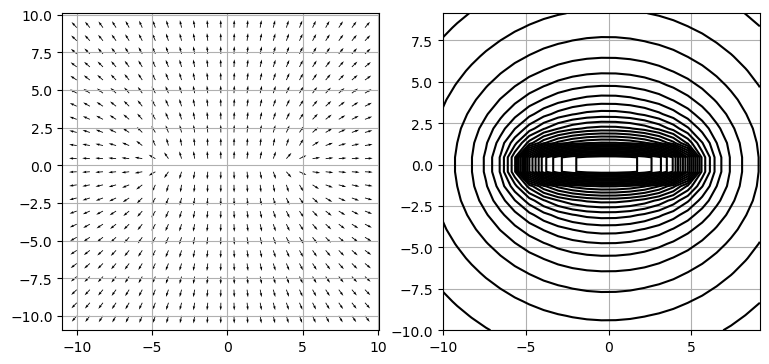

In [4]:
# Ячейка № 4

# визуализация векторного поля
# нормированных векторов, сонаправленных
# с векторами напряженности
# электростатического поля,
# созданного линейной системой
# электрических зарядов

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(1, 2, 1)
q = ax.quiver(X1, Y1, px1, py1)
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

# визуализация карты эквипотенциалей модуля напряженности
# электростатического поля, созданного
# линейной системой электрических зарядов
ax = fig.add_subplot(1, 2, 2)
CS = ax.contour(X1, Y1, M, levels=30, colors="black")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

plt.show()